# DCB benchmark: Tijs et al. (2022), AS4D/PEKK-FC

B. H. A. H. Tijs, S. Abdel-Monsef, J. Renart, A. Turon and C. Bisagni, *Characterization and analysis of the interlaminar behavior of thermoplastic composites considering fiber bridging and R-curve effects*, Composites Part A 162 (2022) 107101, https://doi.org/10.1016/j.compositesa.2022.107101.

Mode I cases of the paper (the ENF, CELS and MMB50 cases are mode II or mixed mode and are not included):

- DCB of AS4D/PEKK-FC, 30 unidirectional plies of 0.14 mm ($2h = 4.2$ mm, arms of 2.1 mm), width 25 mm, specimens 225 mm long;
- Table 1: $E_{11}$ = 138.3 GPa (tension) / 128.0 GPa (compression), $E_{22}$ = 10.4 / 11.5 GPa, $G_{12} = G_{13}$ = 5.19 GPa, $\nu_{12}$ = 0.316, matrix tensile strength $Y_T$ = 87 MPa; the analyses use the average of the tensile and compressive moduli;
- tests at the University of Girona (ISO 15024, side-clamped hinges, $a_0$ = 48 mm) and at TU Delft (ASTM D5528, loading blocks, $a_0$ = 40 mm);
- fracture toughness: initiation about 0.7 N/mm, propagation 1.12 N/mm (with fibre bridging), about 0.95 N/mm without the contribution of fibre bridging (Fig. 15);
- ABAQUS/Standard, 2D plane strain CPE4I elements with COH2D4 cohesive elements, mesh of 0.1 mm, $K = 10^6$ N/mm$^3$, beam length $L$ = 100 mm and $a_0$ = 40/48 mm (Table 2). Fig. 25a compares the test with a bilinear law ("Numerical: linear", $G_{Ic}$ = 1.12 N/mm, $\tau^0$ = 87 MPa) and a tabular multilinear law fitted to the test ("Numerical: tabular").

This DCB is the reference case of the MSc thesis of D'Souza (2024) and of the convergence study of `panels`, there with a length of 65 mm.

**Conventions.** The displacement of Figs. 12, 15 and 25 is the opening $\delta$ at the load line.

**Digitised data.** The curves were read from Figs. 15a and 25a by eye, with an estimated uncertainty of $\pm 0.2$ mm and $\pm 3$ N. The test "DCB (2)" of Fig. 15a is taken with $a_0$ = 40 mm (TU Delft): its initial compliance, about 0.030 mm/N, corresponds to $a_0 \approx 42$ mm with the compliance calibration of the autoclave UD specimens of Tijs (2023, Table 5.4.1), while "DCB (1)" is the test of Fig. 12 with $a_0$ = 48 mm.

In [1]:
import os
import sys

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

sys.path.insert(0, os.path.abspath('.'))
import dcb_utils as du

# True runs panels again, otherwise the results saved in RESULTS are loaded
RERUN = False
RESULTS = 'results'
# comma-separated keys, runs only these cases (used to run cases in parallel)
ONLY = os.environ.get('DCB_CASES')
ONLY = ONLY.split(',') if ONLY else None


In [2]:
# AS4D/PEKK-FC, Tijs et al. (2022) Table 1: average of tension and compression moduli,
# as used in the finite element analyses of the paper
pekk = dict(E1=(138300. + 128000.)/2, E2=(10400. + 11500.)/2, nu12=0.316, G12=5190.)


## FE-based DCB cases

In [3]:
dcb = dict(pekk, h=2.1, b=25., L=100.)

fe_cases = {
    'a48': dict(dcb, a0=48., G1c=1.12, tau_o=87., k_o=1.e6,
        label='$a_0$ = 48 mm, $G_{Ic}$ = 1.12 N/mm',
        source='Table 2, Fig. 25a',
        model='ABAQUS/Standard, CPE4I + COH2D4, mesh 0.1 mm, K = 1e6 N/mm3',
        curves={
            'FE, bilinear law (Fig. 25a)': (np.array([0, 5.7, 6.5, 7.5, 8.5, 10., 11.]),
                                            np.array([0, 167., 152., 138., 131., 126., 122.])),
            'FE, tabular law (Fig. 25a)': (np.array([0, 5.0, 5.8, 6.5, 7.5, 8.5, 10., 11.]),
                                           np.array([0, 135., 141., 140., 136., 132., 127., 124.])),
        }),
    'a40': dict(dcb, a0=40., G1c=1.12, tau_o=87., k_o=1.e6,
        label='$a_0$ = 40 mm, $G_{Ic}$ = 1.12 N/mm',
        source='Table 2 (no FE curve shown for this crack length)',
        model='as a48', curves={}),
}


## Experimental DCB tests

In [4]:
exp_tests = {
    'DCB1_a48': dict(fe_case='a48', source='Figs. 12a, 15a and 25a, test "DCB (1)", UdG, a0 = 48 mm',
        curves={'test DCB (1) (Fig. 15a)': (
            np.array([0, 6.3, 7.0, 8.0, 10., 12., 14., 16., 18., 20., 22., 24.]),
            np.array([0, 142., 140., 135., 127., 118., 111., 103., 97., 91., 85., 82.]))},
        notes='Propagation test after a pre-crack; initiation about 0.7 N/mm, propagation 1.12 N/mm.'),
    'DCB2_a40': dict(fe_case='a40', source='Fig. 15a, test "DCB (2)", a0 taken as 40 mm (see above)',
        curves={'test DCB (2) (Fig. 15a)': (
            np.array([0, 4.8, 5.5, 6.0, 7.0, 8.0, 10., 12., 14., 16., 18., 20.]),
            np.array([0, 161., 152., 142., 130., 122., 111., 103., 96., 90., 85., 80.]))},
        notes='Follows LEFM with 0.95 N/mm, smaller influence of fibre bridging.'),
}


## panels model

The DCB is modelled with `dcb_utils.solve_dcb`: CLPT panels, far end clamped, arm tips opened symmetrically to $\pm\delta/2$ by prescribed displacements, a cohesive domain (`SB_TSL`, bilinear law) ahead of the initial crack front and a perfect bond (`SB`) over the rest of the bonded region. The load is the reaction of the prescribed displacement. When the bonded strip is narrower than the arms (`bond_width`), the integration points outside the strip start fully damaged.

The discretisation follows the rules of the convergence study (`theory/multidomain_penalization/cohesive_zone_deviations_from_thesis.tex`): $m_{tsl} = 1.5\,\lambda L_{tsl}$ terms along $x$ of the cohesive domain (at most 25), with $\lambda = (k_o/4D_{11})^{1/4}$, and $n_x = 10\,L_{tsl}/l_{cz}$ Gauss points (at most 300), with $l_{cz} = 0.88\,E_2 G_{Ic}/\tau_o^2$. The cohesive domain covers the crack growth up to the last opening plus a margin of $2\pi/\lambda + 3 l_{cz}$. The penalty stiffness is $k_o = 10^5$ N/mm$^3$ instead of the $10^6$ N/mm$^3$ of the references: the peak load changes by 0.03% between both values in the Turon et al. (2007) case (see `turon2007_dcb.ipynb`).


In [5]:
def setup(case, k_o=1.e5, growth_max=None, n_steps=60):
    """Cohesive domain, discretisation and openings of a panels run"""
    c = dict(case)
    c['k_o'] = k_o
    lam, lcz, L_max = du.resolution(c)
    margin = 2*np.pi/lam + 3*lcz
    L_avail = c['L'] - c['a0']
    growth = min(L_max, L_avail) - margin
    if growth_max is not None:
        growth = min(growth, growth_max)
    L_tsl = min(growth + margin, L_avail)
    c = du.discretize(c, L_tsl)
    # opening when the crack reaches a0 + growth, corrected beam theory
    EI = du.D11(c)*c['b']
    dh = du.chi_williams(du.bending_modulus(c), c['E2'], c['G12'])*du.arm_thickness(c)
    ae = c['a0'] + growth + dh
    delta_max = 2/3*ae**2*np.sqrt(c['G1c']*du._bonded_width(c)/EI)
    openings = np.linspace(delta_max/n_steps, delta_max, n_steps)
    print(f"{case.get('label', '')}: lambda={lam:.3f} 1/mm, lcz={lcz:.2f} mm, "
          f"L_tsl={c['L_tsl']:.1f} mm, m_tsl={c['m_tsl']}, nx={c['nx']}, "
          f"delta_max={delta_max:.2f} mm")
    return c, openings


def run(key, case, openings, path):
    if ONLY is not None and key not in ONLY:
        return None
    return du.run_or_load(case, openings, path, rerun=RERUN)


def compliance_case(case):
    """Linear elastic model to evaluate the compliance"""
    c = dict(case)
    c.update(k_o=1.e5, tau_o=87., L_tsl=20., m_tsl=15, nx=60)
    return c


def curve(res):
    return np.concatenate(([0.], res['delta'])), np.concatenate(([0.], res['P']))


def plot_compare(rows, title, xmax=None):
    fig, ax = plt.subplots(figsize=(7, 4.5))
    style = {}
    for k in rows:
        if k.startswith('panels'):
            style[k] = dict(lw=2, color='k') if '1e6' not in k else dict(lw=1.5, color='0.5')
        elif 'LEFM' in k:
            style[k] = dict(ls='--', lw=1)
        elif 'test' in k.lower() or 'experiment' in k.lower():
            style[k] = dict(ls='none', marker='o', mfc='none', ms=4)
        else:
            style[k] = dict(marker='s', ms=3)
    du.plot_curves(ax, rows, style)
    if xmax:
        ax.set_xlim(0, xmax)
    ax.set_title(title)
    plt.show()


def report(key, case, res):
    print(f"panels {key}: m_tsl={case['m_tsl']}, nx={case['nx']}, {len(res['delta'])} openings, "
          f"{res['failed']} bisections, crack growth {res['a'][-1] - case['a0']:.1f} mm")


In [6]:
runs = {}
for key in ['a48', 'a40']:
    case, openings = setup(fe_cases[key])
    runs[key] = (case, run(key, case, openings, f'{RESULTS}/tijs2022_{key}.npz'))


$a_0$ = 48 mm, $G_{Ic}$ = 1.12 N/mm: lambda=0.701 1/mm, lcz=1.43 mm, L_tsl=23.8 mm, m_tsl=25, nx=170, delta_max=8.51 mm
$a_0$ = 40 mm, $G_{Ic}$ = 1.12 N/mm: lambda=0.701 1/mm, lcz=1.43 mm, L_tsl=23.8 mm, m_tsl=25, nx=170, delta_max=6.47 mm


## Comparison

### $a_0$ = 48 mm, $G_{Ic}$ = 1.12 N/mm

| curve | K0 (N/mm) | Pmax (N) | delta at Pmax (mm) | dK0, dPmax, d(delta) vs FE, bilinear law (Fig. 25a) | dK0, dPmax, d(delta) vs test DCB (1) (Fig. 15a) |
|---|---|---|---|---|---|
| FE, bilinear law (Fig. 25a) | 29.30 | 167.0 | 5.70 | - | +30.0%, +17.6%, -9.5% |
| FE, tabular law (Fig. 25a) | 25.46 | 141.0 | 5.80 | -13.1%, -15.6%, +1.8% | +12.9%, -0.7%, -7.9% |
| test DCB (1) (Fig. 15a) | 22.54 | 142.0 | 6.30 | -23.1%, -15.0%, +10.5% | - |
| panels | 31.90 | 166.2 | 5.68 | +8.9%, -0.5%, -0.4% | +41.5%, +17.0%, -9.9% |
| LEFM, corrected beam theory, 1.12 N/mm | 27.98 | 164.5 | 5.88 | -4.5%, -1.5%, +3.1% | +24.1%, +15.8%, -6.7% |
| LEFM, corrected beam theory, 0.7 N/mm | 27.98 | 130.0 | 4.65 | -4.5%, -22.1%, -18.5% | +24.1%, -8.4%, -26.2% |

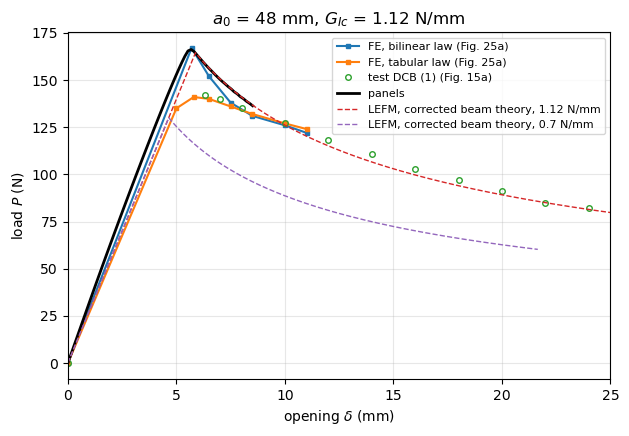

panels a48: m_tsl=25, nx=170, 60 openings, 0 bisections, crack growth 11.8 mm


In [7]:
def compare(key, exp_key, extra_G=()):
    fe = fe_cases[key]
    case, res = runs[key]
    rows = dict(fe['curves'])
    rows.update(exp_tests[exp_key]['curves'])
    rows['panels'] = curve(res)
    rows['LEFM, corrected beam theory, 1.12 N/mm'] = du.lefm_curve(fe, fe['a0'] + 60, corrected=True)
    for G in extra_G:
        rows[f'LEFM, corrected beam theory, {G} N/mm'] = du.lefm_curve(dict(fe, G1c=G), fe['a0'] + 60, corrected=True)
    refs = [k for k in rows if 'FE' in k][:1] + list(exp_tests[exp_key]['curves'])[:1]
    display(Markdown(f"### {fe['label']}\n\n" + du.markdown_table(rows, ref=refs)))
    plot_compare(rows, fe['label'], xmax=25)
    report(key, case, res)

compare('a48', 'DCB1_a48', extra_G=(0.7,))


### $a_0$ = 40 mm, $G_{Ic}$ = 1.12 N/mm

| curve | K0 (N/mm) | Pmax (N) | delta at Pmax (mm) | dK0, dPmax, d(delta) vs test DCB (2) (Fig. 15a) |
|---|---|---|---|---|
| test DCB (2) (Fig. 15a) | 33.54 | 161.0 | 4.80 | - |
| panels | 54.16 | 197.5 | 3.99 | +61.5%, +22.7%, -16.9% |
| LEFM, corrected beam theory, 1.12 N/mm | 46.29 | 194.5 | 4.20 | +38.0%, +20.8%, -12.5% |
| LEFM, corrected beam theory, 0.95 N/mm | 46.29 | 179.1 | 3.87 | +38.0%, +11.3%, -19.4% |

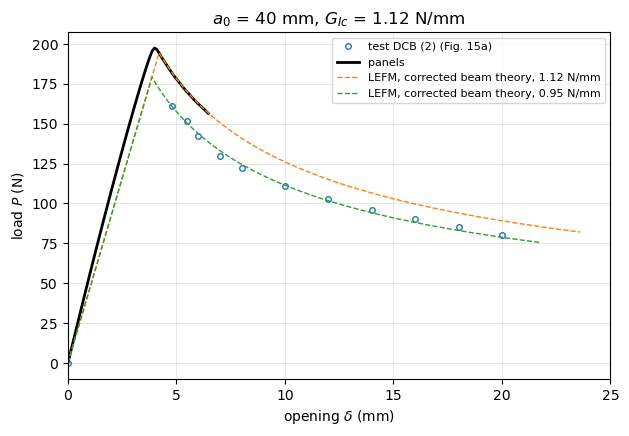

panels a40: m_tsl=25, nx=170, 60 openings, 0 bisections, crack growth 11.8 mm


In [8]:
compare('a40', 'DCB2_a40', extra_G=(0.95,))

## Discussion

- **Same bilinear law, $a_0$ = 48 mm.** panels predicts 166.2 N at an opening of 5.68 mm. The FE model of the paper with the same bilinear law ($G_{Ic}$ = 1.12 N/mm, $\tau^0$ = 87 MPa) peaks at about 167 N at about 5.7 mm (Fig. 25a): the difference is 0.5% on the load and 0.4% on the opening, the closest comparison of all the validation cases, since the geometry, the material and the cohesive law are the same. The corrected beam theory gives 164.5 N (+1.0%).
- **Test with R-curve.** The test peaks at about 142 N, 15% below the bilinear models. The paper explains the difference by the R-curve: the initiation toughness is about 0.7 N/mm and the propagation toughness of 1.12 N/mm is only reached after fibre bridging develops. The tabular multilinear law fitted to the test reproduces it (about 141 N), while a bilinear law with the propagation toughness cannot, which is also the conclusion of the paper. A multilinear law is not available in `panels`.
- **$a_0$ = 40 mm.** No FE curve is given for this crack length. panels predicts 197.5 N, 1.5% above the corrected beam theory; the test DCB (2) peaks at about 161 N and follows the LEFM curve with 0.95 N/mm (Fig. 15a), again reflecting the R-curve.
- **Initial stiffness.** panels is 9% stiffer than the FE model and 14-17% stiffer than the corrected beam theory, see `lecinana2023_dcb.ipynb` and `tijs2023_phd_dcb.ipynb` for the measured compliances. The tests are more compliant than all models, which the compliance calibration of these specimens attributes to a crack length correction of 9.18 mm (Tijs 2023, Table 5.4.1), 2.4 times the $\chi h$ = 3.8 mm of the corrected beam theory.
- **Robustness.** Both runs converged at every opening without bisection, with 11.8 mm of crack growth.